# Loan Risk Classification — Grade A–G

**Structure:**
- `config.py` — paths, seed, device
- `data_processing.py` — feature engineering, ML & DL preprocessors
- `models.py` — FFNN, TabNet, TabTransformer, training loop, evaluation
- `ml_pipeline.py` — RF, KNN, SVM grid search wrappers

This notebook is the **control panel**: import modules, set hyperparameters,
launch training, evaluate.

## 0. Setup & Imports

In [1]:
import sys
import os

# Add src/ to path so we can import our modules
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from config import SEED, DEVICE, MODEL_DIR, TRAIN_CSV, fix_random
from data_processing import (
    load_data,
    feature_engineer,
    build_ml_preprocessor,
    prepare_ml_data,
    prepare_dl_data,
)
from ml_pipeline import (
    train_random_forest,
    train_knn,
    train_svm,
    save_model,
    print_grid_results,
    plot_rf_feature_importances,
)
from models import (
    LoanDataset,
    TabularDataset,
    LoanClassifierFFNN,
    build_tabnet_classifier,
    train_tabnet,
    build_tab_transformer,
    train_model,
    evaluate_model,
    plot_losses,
    plot_confusion_matrix,
    plot_feature_importances,
    get_class_weights,
    get_class_weights_dict,
    create_loaders,
)

fix_random(SEED)
print(f"Device: {DEVICE}")

Device: mps


## 1. Data Loading & Exploration

In [2]:
df = load_data(TRAIN_CSV)
df.head()

Loaded 148301 rows  (dropped 0 duplicates)


,loan_contract_approved_amount,loan_portfolio_total_funded,investor_side_funded_amount,loan_contract_term_months,loan_contract_interest_rate,loan_payment_installments_count,borrower_profile_employment_length,borrower_housing_ownership_status,borrower_income_annual,borrower_income_verification_status,...,hardship_last_payment_amount_total,disbursement_method_type,debt_settlement_flag_indicator,debt_settlement_flag_date,settlement_status_label,settlement_date,settlement_amount_total,settlement_percentage,settlement_term_months,grade
0,12000.0,11819.212488,12000.000000,36 months,12.806304,395.66,10+ years,rent,40000.0,source verified,...,NaN,cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
1,10000.0,10683.410001,10023.226279,36 months,7.890000,312.86,2 years,rent,NaN,not verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,A
2,7000.0,7000.000000,5989.447426,36 months,18.558177,253.04,8 years,mortgage,120000.0,source verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,D
3,35000.0,35000.000000,35000.000000,60 months,22.950000,985.67,NaN,mortgage,99588.0,verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,F
4,2400.0,2437.596602,2400.000000,36 months,13.990000,82.02,2 years,rent,37000.0,source verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,C


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148301 entries, 0 to 148300
Columns: 145 entries, loan_contract_approved_amount to grade
dtypes: float64(112), object(33)
memory usage: 164.1+ MB


/var/folders/c4/m_6w9kxs5kj6jyfn6b9_dsbr0000gn/T/ipykernel_11845/3926484378.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


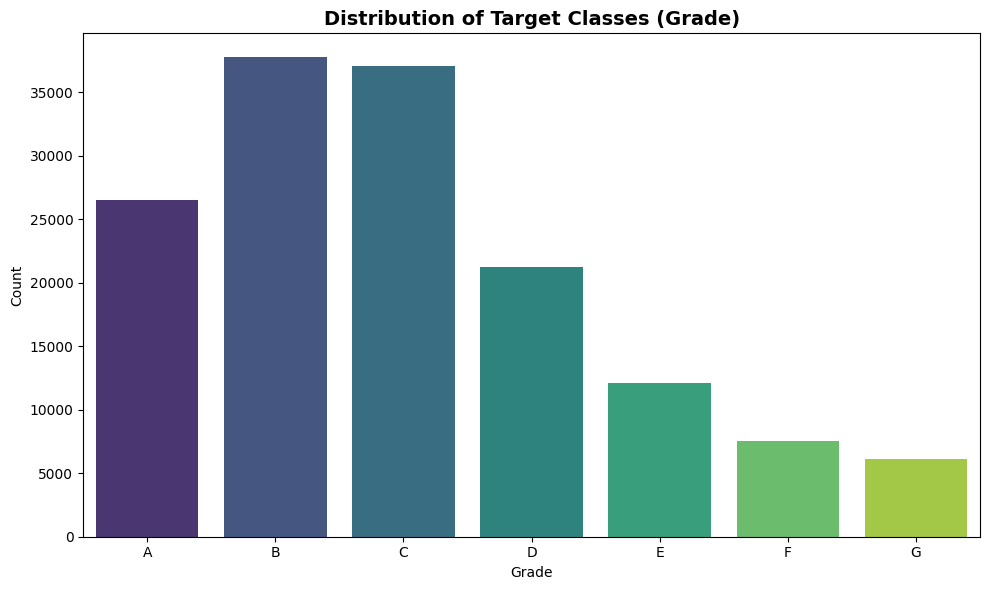

In [4]:
# Target distribution
class_counts = df["grade"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution of Target Classes (Grade)", fontsize=14, fontweight="bold")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

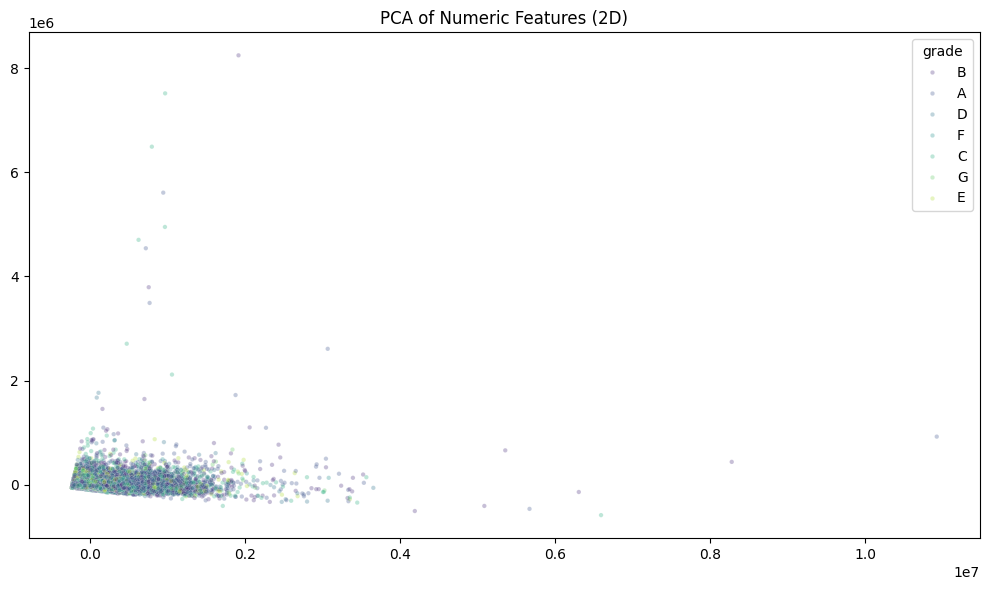

In [5]:
# PCA visualization
from sklearn.decomposition import PCA

X_numeric = df.select_dtypes(include=[np.number]).fillna(0)
X_pca = PCA(n_components=2).fit_transform(X_numeric)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["grade"], palette="viridis", alpha=0.3, s=10)
plt.title("PCA of Numeric Features (2D)")
plt.tight_layout()
plt.show()

## 2. ML Models (Full-Data Cross-Validation)

The ML pipeline uses **all** the data with `GridSearchCV` (3-fold stratified CV).
Preprocessing is embedded inside the pipeline, so there is no data leakage.

In [37]:
# Prepare ML data (loads, engineers, builds preprocessor)
X_ml, y_ml, col_lists, preprocessor, global_scaler, le_ml = prepare_ml_data(TRAIN_CSV)
print(f"\nML data ready: X={X_ml.shape}, y={y_ml.shape}")

Loaded 148301 rows  (dropped 0 duplicates)
Dropped 42 cols with >50% missing
Dropped 10 collinear cols


/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:211: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["loan_contract_term_months"].fillna(mode_val, inplace=True)
/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:223: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

Feature engineering done  ->  118 features
  normal_dist      : 33
  safe_log_cols    : 69
  negative_cols    : 3
  ordinal_cols     : 6
  one_hot_cols     : 5
  target_encode_cols: 2

ML data ready: X=(148301, 118), y=(148301,)


### 2.1 Random Forest

In [38]:
# Hyperparameters — edit here
rf_param_grid = {
    "classifier__n_estimators": [500],
    "classifier__max_depth": [None],
    "classifier__min_samples_split": [8],
    "classifier__min_samples_leaf": [1],
    "classifier__max_features": ["sqrt", 0.3],
}

gs_rf = train_random_forest(X_ml, y_ml, preprocessor, param_grid=rf_param_grid)

Starting Random Forest GridSearch...
Random Forest GridSearch complete.


In [39]:
# Save & inspect (separate cell — re-run without retraining)
try:
    save_model(gs_rf.best_estimator_, "rf")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_rf, "Random Forest")

Model saved to ./models/rf.pkl

  Random Forest — Best GridSearch Results
  Best Params: {'classifier__max_depth': None, 'classifier__max_features': 0.3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 500}

  accuracy                 : 0.9652 ± 0.0005
  balanced_accuracy        : 0.9550 ± 0.0008
  f1_weighted              : 0.9652 ± 0.0005
  f1_macro                 : 0.9568 ± 0.0008



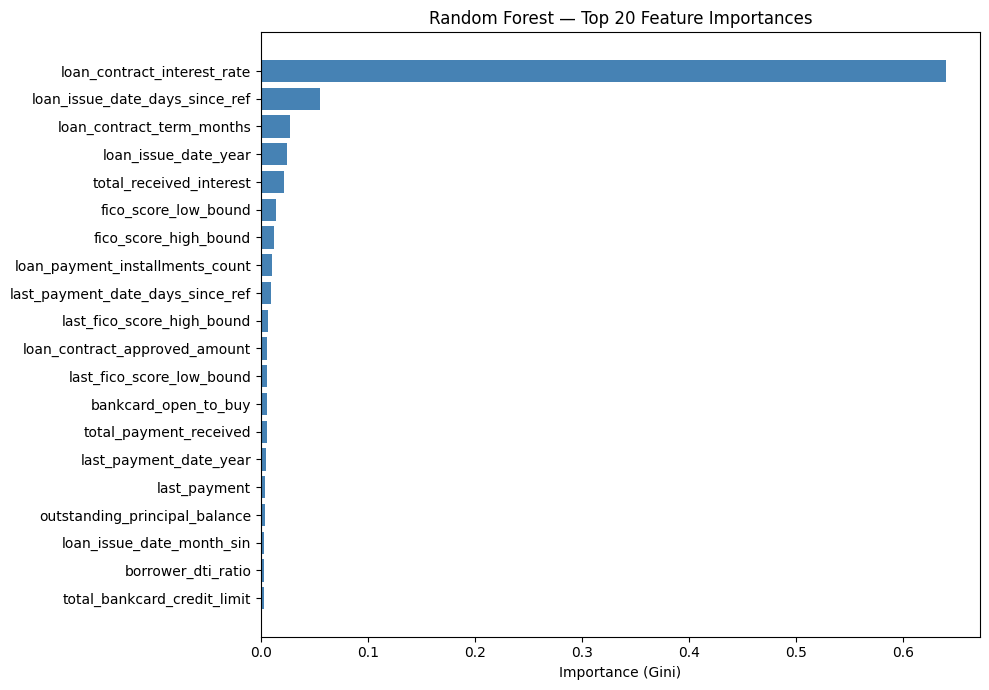

In [40]:
plot_rf_feature_importances(gs_rf, top_k=20)

### 2.2 KNN

In [41]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

knn_param_grid = {
    "pca__n_components": [20, 40, None],
    "scaler__scaler_op": [RobustScaler(), StandardScaler(), MinMaxScaler()],
    "classifier__n_neighbors": [30, 50, 100],
    "classifier__weights": ["distance"],
    "classifier__p": [1, 2],
}

gs_knn = train_knn(X_ml, y_ml, preprocessor, global_scaler, param_grid=knn_param_grid)

Starting KNN GridSearch...


/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KNN GridSearch complete.


In [42]:
try:
    save_model(gs_knn.best_estimator_, "knn")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_knn, "KNN")

Model saved to ./models/knn.pkl

  KNN — Best GridSearch Results
  Best Params: {'classifier__n_neighbors': 30, 'classifier__p': 2, 'classifier__weights': 'distance', 'pca__n_components': 40, 'scaler__scaler_op': StandardScaler()}

  accuracy                 : 0.4184 ± 0.0029
  balanced_accuracy        : 0.3118 ± 0.0026
  f1_weighted              : 0.3969 ± 0.0026
  f1_macro                 : 0.3212 ± 0.0028



### 2.3 SVM

In [43]:
svm_param_grid = {
    "scaler__scaler_op": [RobustScaler(), StandardScaler(), MinMaxScaler()],
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__kernel": ["linear", "poly", "rbf"],
    "classifier__gamma": ["scale"],
}

gs_svm = train_svm(X_ml, y_ml, preprocessor, global_scaler, param_grid=svm_param_grid)

Starting SVM GridSearch...


/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ma3ti/miniconda3/

SVM GridSearch complete.


/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [44]:
try:
    save_model(gs_svm.best_estimator_, "svm")
except Exception as e:
    print(f"Error saving model: {e}")
    
print_grid_results(gs_svm, "SVM")

Model saved to ./models/svm.pkl

  SVM — Best GridSearch Results
  Best Params: {'classifier__C': 100, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'scaler__scaler_op': StandardScaler()}

  accuracy                 : 0.6404 ± 0.0047
  balanced_accuracy        : 0.5974 ± 0.0082
  f1_weighted              : 0.6370 ± 0.0040
  f1_macro                 : 0.6008 ± 0.0071



## 3. Deep Learning Models (80/10/10 Split)

DL uses an explicit train/val/test split. Preprocessing is fit on train only.

In [ ]:
# Prepare DL data
#TODO: check if data are splitted in a balanced way
dl_data = prepare_dl_data(TRAIN_CSV, val_size=0.10, test_size=0.10)

print(f"\nDL data shapes:")
print(f"  X_train: {dl_data['X_train'].shape}")
print(f"  X_val  : {dl_data['X_val'].shape}")
print(f"  X_test : {dl_data['X_test'].shape}")
print(f"  Num cols: {dl_data['num_num_cols']}, Cat cols: {dl_data['num_cat_cols']}")
print(f"  Classes : {dl_data['num_classes']}")
print(f"  Cat cardinalities: {dl_data['cat_cardinalities']}")
print(f"  Feature names ({len(dl_data['feature_names'])}): {dl_data['feature_names'][:10]}...")

Loaded 148301 rows  (dropped 0 duplicates)
Train: 118639 (80.0%)
Val  : 14831 (10.0%)
Test : 14831 (10.0%)
Dropped 42 cols with >50% missing
Dropped 10 collinear cols


/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:211: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["loan_contract_term_months"].fillna(mode_val, inplace=True)
/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:223: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

Feature engineering done  ->  118 features
  normal_dist      : 33
  safe_log_cols    : 69
  negative_cols    : 3
  ordinal_cols     : 6
  one_hot_cols     : 5
  target_encode_cols: 2
Dropped 42 cols with >50% missing
Dropped 10 collinear cols


/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:211: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["loan_contract_term_months"].fillna(mode_val, inplace=True)
/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:223: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

Feature engineering done  ->  118 features
  normal_dist      : 33
  safe_log_cols    : 69
  negative_cols    : 3
  ordinal_cols     : 6
  one_hot_cols     : 5
  target_encode_cols: 2
Dropped 42 cols with >50% missing
Dropped 9 collinear cols
Feature engineering done  ->  119 features
  normal_dist      : 35
  safe_log_cols    : 68
  negative_cols    : 3
  ordinal_cols     : 6
  one_hot_cols     : 5
  target_encode_cols: 2


/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:211: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["loan_contract_term_months"].fillna(mode_val, inplace=True)
/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:223: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 


DL data shapes:
  X_train: (118639, 118)
  X_val  : (14831, 118)
  X_test : (14831, 118)
  Num cols: 105, Cat cols: 13
  Classes : 7
  Cat cardinalities: [5, 4, 4, 53, 4, 4, 4, 4, 4, 6, 880, 8, 15]
  Feature names (118): ['loan_contract_approved_amount', 'loan_contract_term_months', 'loan_contract_interest_rate', 'loan_payment_installments_count', 'borrower_profile_employment_length', 'borrower_income_annual', 'loan_status_current_code', 'borrower_dti_ratio', 'credit_delinquencies_2yrs', 'fico_score_low_bound']...


In [7]:
# Class weights (shared across all DL models)
class_weights_array = get_class_weights(dl_data["y_train"])
class_weights_dict = get_class_weights_dict(dl_data["y_train"])
class_names = [f"Grade {c}" for c in dl_data["label_encoder"].classes_]
feature_names = dl_data["feature_names"]

print(f"Class weights: {dict(enumerate(class_weights_array))}")
print(f"Class names: {class_names}")
print(f"Feature names: {len(feature_names)} total")

Class weights: {0: np.float32(0.7984373), 1: np.float32(0.5614107), 2: np.float32(0.57132745), 3: np.float32(0.9966732), 4: np.float32(1.7532252), 5: np.float32(2.8158214), 6: np.float32(3.4823153)}
Class names: ['Grade A', 'Grade B', 'Grade C', 'Grade D', 'Grade E', 'Grade F', 'Grade G']
Feature names: 118 total


In [46]:
for name, y in [("Train", dl_data["y_train"]),
                ("Val",   dl_data["y_val"]),
                ("Test",  dl_data["y_test"])]:
    unique, counts = np.unique(y, return_counts=True)
    pcts = counts / counts.sum() * 100
    print(f"{name:5s}: {dict(zip(unique, [f'{p:.1f}%' for p in pcts]))}")

Train: {np.int64(0): '17.9%', np.int64(1): '25.4%', np.int64(2): '25.0%', np.int64(3): '14.3%', np.int64(4): '8.1%', np.int64(5): '5.1%', np.int64(6): '4.1%'}
Val  : {np.int64(0): '17.9%', np.int64(1): '25.4%', np.int64(2): '25.0%', np.int64(3): '14.3%', np.int64(4): '8.1%', np.int64(5): '5.1%', np.int64(6): '4.1%'}
Test : {np.int64(0): '17.9%', np.int64(1): '25.4%', np.int64(2): '25.0%', np.int64(3): '14.3%', np.int64(4): '8.1%', np.int64(5): '5.1%', np.int64(6): '4.1%'}


### 3.1 Feed-Forward Neural Network (FFNN)

In [27]:
# ── FFNN Hyperparameters (edit here) ──
FFNN_HP = dict(
    # Architecture
    hidden_units=[256, 128, 64],
    dropout_rates=[0.3, 0.05],
    # Training
    num_epochs=300,
    batch_size=256,
    learning_rate=3e-4,
    weight_decay=1e-4,
    patience=25,
    scheduler_patience=5,
    scheduler_factor=0.3,
)

In [28]:
# Build datasets and loaders
train_ds = LoanDataset(dl_data["X_train"], dl_data["y_train"])
val_ds   = LoanDataset(dl_data["X_val"],   dl_data["y_val"])
test_ds  = LoanDataset(dl_data["X_test"],  dl_data["y_test"])

train_loader, val_loader, test_loader = create_loaders(
    train_ds, val_ds, test_ds, batch_size=FFNN_HP["batch_size"]
)

print(f"Input dim: {train_ds.num_features}, Output dim: {train_ds.num_classes}")

Input dim: 118, Output dim: 7


In [29]:
# Build & train FFNN
fix_random(SEED)

ffnn_model = LoanClassifierFFNN(
    input_dim=train_ds.num_features,
    output_dim=train_ds.num_classes,
    hidden_units=FFNN_HP["hidden_units"],
    dropout_rates=FFNN_HP["dropout_rates"],
).to(DEVICE)

print(ffnn_model)
print(f"Parameters: {sum(p.numel() for p in ffnn_model.parameters()):,}")

LoanClassifierFFNN(
  (fc1): Linear(in_features=118, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (ln3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop3): Dropout(p=0.3, inplace=False)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (ln4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (drop4): Dropout(p=0.05, inplace=False)
  (out): Linear(in_features=64, out_features=7, bias=True)
)
Parameters: 89,735


Epoch   1/300 | Train 1.8206 | Val 1.3895 | LR 3.00e-04 | ★ best
Epoch   2/300 | Train 1.1279 | Val 0.7788 | LR 3.00e-04 | ★ best
Epoch   3/300 | Train 0.8334 | Val 0.6397 | LR 3.00e-04 | ★ best
Epoch   4/300 | Train 0.7348 | Val 0.5784 | LR 3.00e-04 | ★ best
Epoch   5/300 | Train 0.6885 | Val 0.5759 | LR 3.00e-04 | ★ best
Epoch   6/300 | Train 0.6607 | Val 0.5416 | LR 3.00e-04 | ★ best
Epoch   7/300 | Train 0.6377 | Val 0.5679 | LR 3.00e-04 | no improve 1/25
Epoch   8/300 | Train 0.6194 | Val 0.5473 | LR 3.00e-04 | no improve 2/25
Epoch   9/300 | Train 0.6055 | Val 0.5161 | LR 3.00e-04 | ★ best
Epoch  10/300 | Train 0.5928 | Val 0.4961 | LR 3.00e-04 | ★ best
Epoch  11/300 | Train 0.5817 | Val 0.4836 | LR 3.00e-04 | ★ best
Epoch  12/300 | Train 0.5691 | Val 0.4871 | LR 3.00e-04 | no improve 1/25
Epoch  13/300 | Train 0.5595 | Val 0.4879 | LR 3.00e-04 | no improve 2/25
Epoch  14/300 | Train 0.5531 | Val 0.4659 | LR 3.00e-04 | ★ best
Epoch  15/300 | Train 0.5434 | Val 0.4841 | LR 3.00e-0

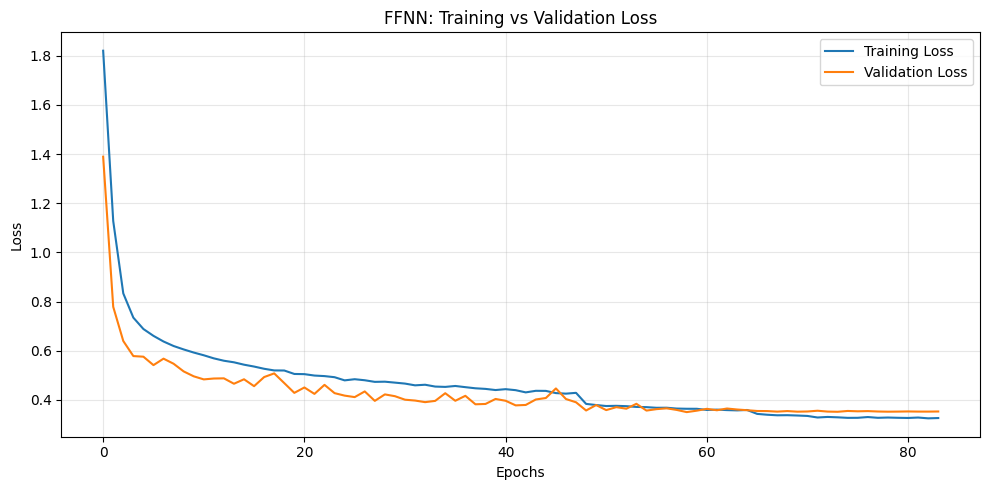

In [30]:
ffnn_model, t_losses, v_losses = train_model(
    model=ffnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=FFNN_HP["num_epochs"],
    patience=FFNN_HP["patience"],
    learning_rate=FFNN_HP["learning_rate"],
    weight_decay=FFNN_HP["weight_decay"],
    scheduler_patience=FFNN_HP["scheduler_patience"],
    scheduler_factor=FFNN_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_ffnn.pkl",
    model_type="standard",
)

plot_losses(t_losses, v_losses, title="FFNN: Training vs Validation Loss")


  FFNN Test Set Evaluation
  Accuracy          : 0.9086
  Balanced Accuracy : 0.8704
  F1 (weighted)     : 0.9090
  F1 (macro)        : 0.8629

              precision    recall  f1-score   support

     Grade A       0.92      0.98      0.95      2654
     Grade B       0.96      0.91      0.94      3774
     Grade C       0.94      0.95      0.94      3708
     Grade D       0.92      0.90      0.91      2126
     Grade E       0.83      0.83      0.83      1208
     Grade F       0.69      0.69      0.69       753
     Grade G       0.73      0.85      0.78       608

    accuracy                           0.91     14831
   macro avg       0.86      0.87      0.86     14831
weighted avg       0.91      0.91      0.91     14831



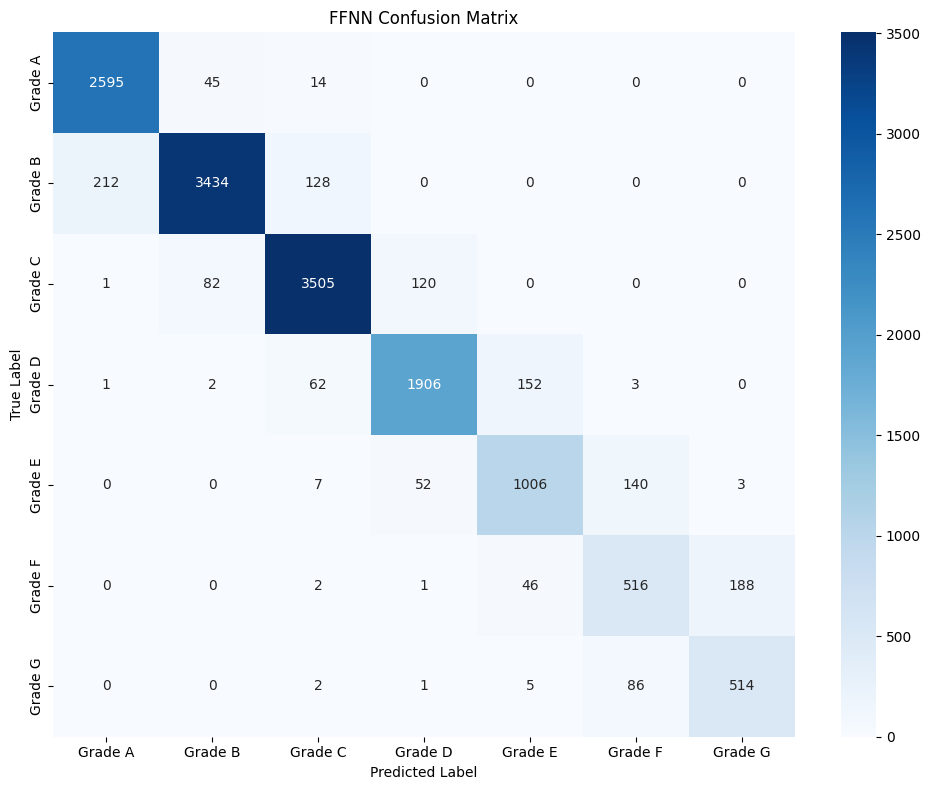

In [31]:
# Evaluate FFNN
ffnn_results = evaluate_model(
    ffnn_model, test_loader, DEVICE,
    class_names=class_names, model_type="standard", set_name="FFNN Test"
)
plot_confusion_matrix(ffnn_results["y_true"], ffnn_results["y_pred"],
                      class_names=class_names, title="FFNN Confusion Matrix")

### 3.2 TabNet

In [32]:
# ── TabNet Hyperparameters (edit here) ──
TABNET_HP = dict(
    # Architecture
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    cat_emb_dim=8,
    # Optimization
    lr=0.02,
    scheduler_step_size=50,
    scheduler_gamma=0.9,
    # Regularization
    lambda_sparse=1e-4,
    momentum=0.3,
    mask_type="sparsemax",
    # Training
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
)

In [33]:
# Build TabNet
tabnet_model = build_tabnet_classifier(
    cat_indices=dl_data["cat_indices"],
    cat_cardinalities=dl_data["cat_cardinalities"],
    device=DEVICE,
    seed=SEED,
    n_d=TABNET_HP["n_d"],
    n_a=TABNET_HP["n_a"],
    n_steps=TABNET_HP["n_steps"],
    gamma=TABNET_HP["gamma"],
    n_independent=TABNET_HP["n_independent"],
    n_shared=TABNET_HP["n_shared"],
    cat_emb_dim=TABNET_HP["cat_emb_dim"],
    lr=TABNET_HP["lr"],
    scheduler_step_size=TABNET_HP["scheduler_step_size"],
    scheduler_gamma=TABNET_HP["scheduler_gamma"],
    lambda_sparse=TABNET_HP["lambda_sparse"],
    momentum=TABNET_HP["momentum"],
    mask_type=TABNET_HP["mask_type"],
)

/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : mps
  warnings.warn(f"Device used : {self.device}")


In [34]:
# Train TabNet
tabnet_model = train_tabnet(
    model=tabnet_model,
    X_train=dl_data["X_train"],
    y_train=dl_data["y_train"],
    X_val=dl_data["X_val"],
    y_val=dl_data["y_val"],
    max_epochs=TABNET_HP["max_epochs"],
    patience=TABNET_HP["patience"],
    batch_size=TABNET_HP["batch_size"],
    virtual_batch_size=TABNET_HP["virtual_batch_size"],
    class_weights=class_weights_dict,
)

/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


epoch 0  | loss: 1.33568 | val_0_logloss: 0.98604 | val_0_accuracy: 0.60401 |  0:00:20s


/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


epoch 1  | loss: 0.7611  | val_0_logloss: 0.62013 | val_0_accuracy: 0.74762 |  0:00:39s


/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


...

/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


epoch 47 | loss: 0.16505 | val_0_logloss: 0.35487 | val_0_accuracy: 0.90574 |  0:15:18s


/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


epoch 48 | loss: 0.15323 | val_0_logloss: 0.32275 | val_0_accuracy: 0.91619 |  0:15:38s

Early stopping occurred at epoch 48 with best_epoch = 28 and best_val_0_accuracy = 0.9292


/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



  TabNet Test Set Evaluation
  Accuracy          : 0.9284
  Balanced Accuracy : 0.9016
  F1 (weighted)     : 0.9282
  F1 (macro)        : 0.9000

              precision    recall  f1-score   support

     Grade A       0.94      0.98      0.96      2654
     Grade B       0.97      0.92      0.94      3774
     Grade C       0.94      0.96      0.95      3708
     Grade D       0.92      0.93      0.93      2126
     Grade E       0.90      0.88      0.89      1208
     Grade F       0.82      0.76      0.79       753
     Grade G       0.81      0.88      0.85       608

    accuracy                           0.93     14831
   macro avg       0.90      0.90      0.90     14831
weighted avg       0.93      0.93      0.93     14831



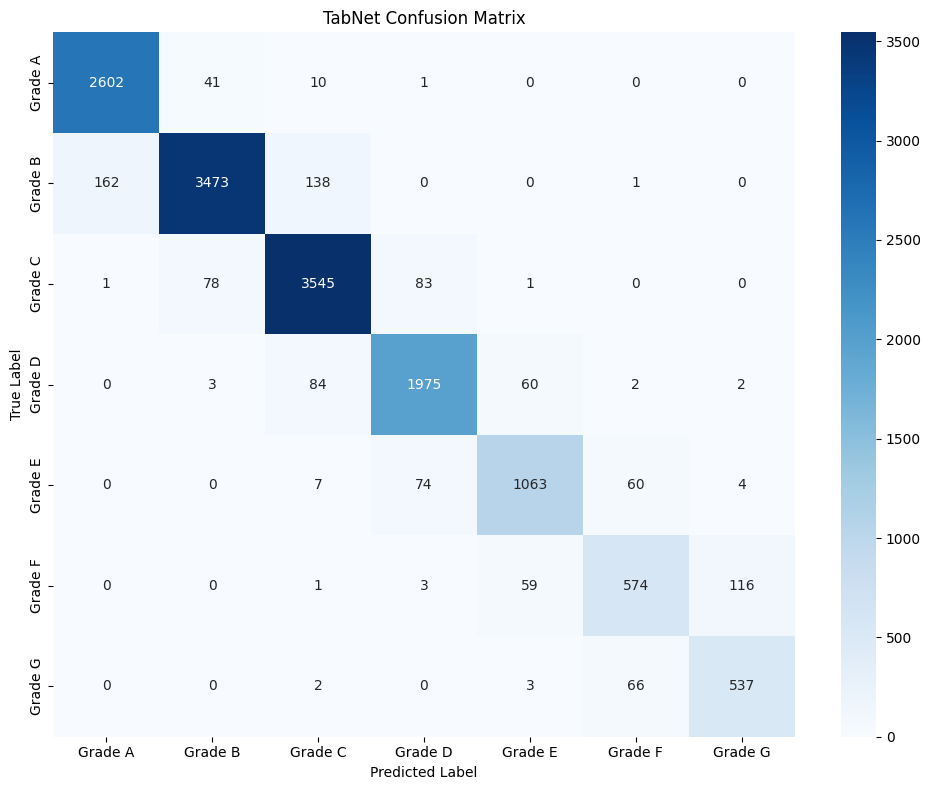

In [35]:
# Evaluate TabNet
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

y_pred_tabnet = tabnet_model.predict(dl_data["X_test"].astype(np.float32))
y_test = dl_data["y_test"]

print(f"\n{'='*50}")
print(f"  TabNet Test Set Evaluation")
print(f"{'='*50}")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  F1 (weighted)     : {f1_score(y_test, y_pred_tabnet, average='weighted'):.4f}")
print(f"  F1 (macro)        : {f1_score(y_test, y_pred_tabnet, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_tabnet, target_names=class_names))

plot_confusion_matrix(y_test, y_pred_tabnet, class_names=class_names, title="TabNet Confusion Matrix")

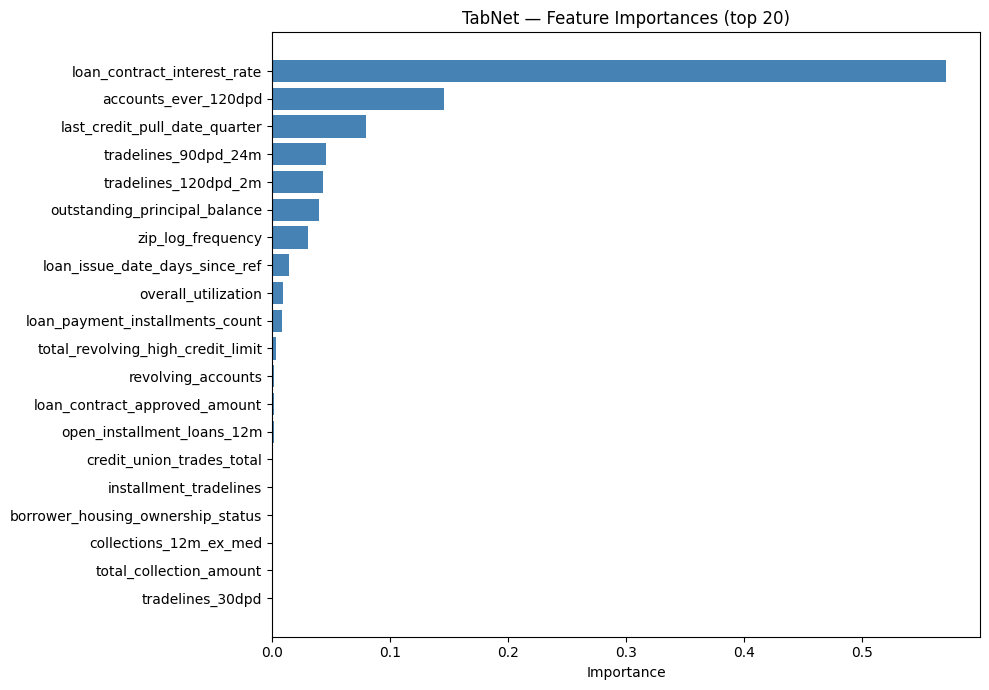

In [36]:
# TabNet feature importances
# tabnet_importances = tabnet_model.feature_importances_
# top_k = 20
# top_indices = np.argsort(tabnet_importances)[-top_k:]

# plt.figure(figsize=(10, 6))
# plt.barh(range(top_k), tabnet_importances[top_indices])
# plt.yticks(range(top_k), [f"Feature {i}" for i in top_indices])
# plt.title(f"TabNet — Top {top_k} Feature Importances")
# plt.xlabel("Importance")
# plt.tight_layout()
# plt.show()

plot_feature_importances(
    importances=tabnet_model.feature_importances_,
    feature_names=feature_names,
    top_k=20,
    title="TabNet — Feature Importances",
)

In [45]:
tabnet_save_path = os.path.join(MODEL_DIR, "best_tabnet")
tabnet_model.save_model(tabnet_save_path)
print(f"TabNet model saved to {tabnet_save_path}")

Successfully saved model at ./models/best_tabnet.zip
TabNet model saved to ./models/best_tabnet


In [47]:
save_model(tabnet_model, "best_tabnet")

Model saved to ./models/best_tabnet.pkl


'./models/best_tabnet.pkl'

### 3.3 Tab Transformer

In [22]:
# ── TabTransformer Hyperparameters (edit here) ──
TABT_HP = dict(
    # Architecture
    dim=32,
    depth=3,
    heads=4,
    attn_dropout=0.4,
    ff_dropout=0.4,
    mlp_hidden_mults=(2, 1),
    # Training
    num_epochs=100,
    batch_size=1024,
    learning_rate=3e-4,
    weight_decay=0.05,
    patience=20,
    #scheduler_patience=7,
    #scheduler_factor=0.5,
    max_grad_norm=1.0,
    use_cosine_scheduler=True,
    warmup_epochs=5,
)

In [23]:
# Build datasets (TabularDataset splits num/cat)
n_num = dl_data["num_num_cols"]

train_ds_tt = TabularDataset(dl_data["X_train"], dl_data["y_train"], n_num)
val_ds_tt   = TabularDataset(dl_data["X_val"],   dl_data["y_val"],   n_num)
test_ds_tt  = TabularDataset(dl_data["X_test"],  dl_data["y_test"],  n_num)

train_loader_tt, val_loader_tt, test_loader_tt = create_loaders(
    train_ds_tt, val_ds_tt, test_ds_tt, batch_size=TABT_HP["batch_size"]
)

print(f"Numeric: {train_ds_tt.n_num}, Categorical: {train_ds_tt.n_cat}")

Numeric: 105, Categorical: 13


In [24]:
# Build & train TabTransformer
fix_random(SEED)

tab_transformer = build_tab_transformer(
    cat_cardinalities=tuple(dl_data["cat_cardinalities"]),
    num_continuous=dl_data["num_num_cols"],
    cont_mean_std=dl_data["cont_mean_std"],
    num_classes=dl_data["num_classes"],
    dim=TABT_HP["dim"],
    depth=TABT_HP["depth"],
    heads=TABT_HP["heads"],
    attn_dropout=TABT_HP["attn_dropout"],
    ff_dropout=TABT_HP["ff_dropout"],
    mlp_hidden_mults=TABT_HP["mlp_hidden_mults"],
    device=DEVICE,
)

print(tab_transformer)
print(f"Parameters: {sum(p.numel() for p in tab_transformer.parameters()):,}")

TabTransformer(
  (categorical_embeds): Embed(
    (embeddings): Embedding(995, 28)
    (selectors): ModuleList(
      (0): DiscreteContinuousSelector(
        (discrete_selector): DiscreteSelector(
          (embeddings): Embedding(995, 28)
        )
      )
    )
  )
  (norm): LayerNorm((105,), eps=1e-05, elementwise_affine=True)
  (special_token_embed): Embedding(2, 28)
  (transformer): Transformer(
    (layers): ModuleList(
      (0-2): 3 x ModuleList(
        (0): HyperConnections(
          (branch): PreNorm(
            (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
            (fn): Attention(
              (to_qkv): Linear(in_features=32, out_features=192, bias=False)
              (to_out): Linear(in_features=64, out_features=32, bias=True)
              (dropout): Dropout(p=0.4, inplace=False)
            )
          )
          (act): Tanh()
          (split_fracs): Rearrange('b ... (f d) -> b ... f d', f=1)
          (merge_fracs): Rearrange('b ... f d -> b .

Epoch   1/100 | Train 1.9435 | Val 1.9196 | LR 6.24e-05 | ★ best
Epoch   2/100 | Train 1.6433 | Val 1.4390 | LR 1.22e-04 | ★ best
Epoch   3/100 | Train 1.2873 | Val 1.1820 | LR 1.81e-04 | ★ best
Epoch   4/100 | Train 1.0671 | Val 0.9764 | LR 2.41e-04 | ★ best
Epoch   5/100 | Train 0.9304 | Val 0.8322 | LR 3.00e-04 | ★ best
Epoch   6/100 | Train 0.7679 | Val 0.7443 | LR 3.00e-04 | ★ best
Epoch   7/100 | Train 0.6932 | Val 0.7006 | LR 3.00e-04 | ★ best
Epoch   8/100 | Train 0.6554 | Val 0.6828 | LR 2.99e-04 | ★ best
Epoch   9/100 | Train 0.6190 | Val 0.6655 | LR 2.99e-04 | ★ best
Epoch  10/100 | Train 0.5887 | Val 0.6026 | LR 2.98e-04 | ★ best
Epoch  11/100 | Train 0.5622 | Val 0.6065 | LR 2.97e-04 | no improve 1/20
Epoch  12/100 | Train 0.5411 | Val 0.5760 | LR 2.96e-04 | ★ best
Epoch  13/100 | Train 0.5170 | Val 0.6052 | LR 2.95e-04 | no improve 1/20
Epoch  14/100 | Train 0.4942 | Val 0.5685 | LR 2.93e-04 | ★ best
Epoch  15/100 | Train 0.4710 | Val 0.5536 | LR 2.92e-04 | ★ best
Epoch  

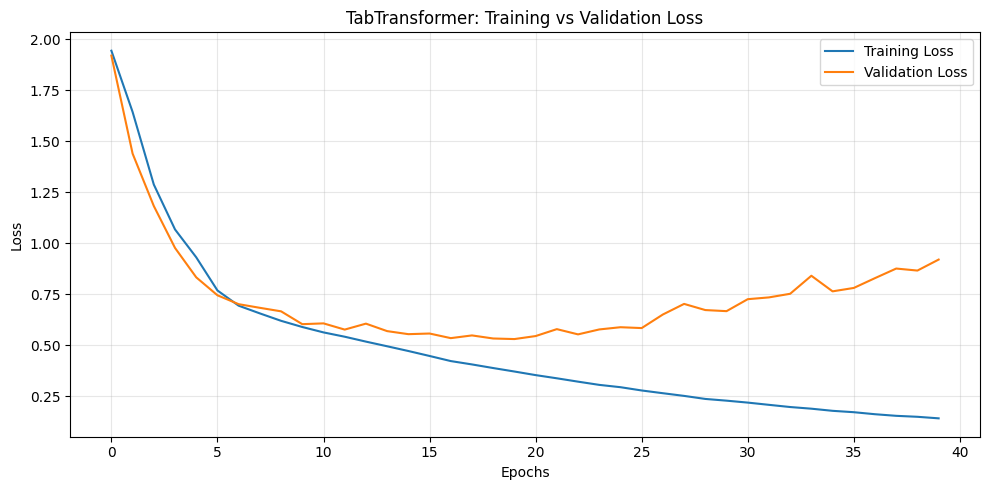

In [25]:
tab_transformer, t_losses_tt, v_losses_tt = train_model(
    model=tab_transformer,
    train_loader=train_loader_tt,
    val_loader=val_loader_tt,
    num_epochs=TABT_HP["num_epochs"],
    patience=TABT_HP["patience"],
    learning_rate=TABT_HP["learning_rate"],
    weight_decay=TABT_HP["weight_decay"],
    #scheduler_patience=TABT_HP["scheduler_patience"],
    #scheduler_factor=TABT_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_tab_transformer.pkl",
    model_type="tab_transformer",
    max_grad_norm=TABT_HP.get("max_grad_norm"),
    use_cosine_scheduler=TABT_HP.get("use_cosine_scheduler", False),
    warmup_epochs=TABT_HP.get("warmup_epochs", 0)
)

plot_losses(t_losses_tt, v_losses_tt, title="TabTransformer: Training vs Validation Loss")


  TabTransformer Test Set Evaluation
  Accuracy          : 0.8525
  Balanced Accuracy : 0.7955
  F1 (weighted)     : 0.8531
  F1 (macro)        : 0.7830

              precision    recall  f1-score   support

     Grade A       0.93      0.94      0.94      2654
     Grade B       0.92      0.89      0.90      3774
     Grade C       0.91      0.88      0.89      3708
     Grade D       0.82      0.85      0.84      2126
     Grade E       0.73      0.71      0.72      1208
     Grade F       0.55      0.48      0.51       753
     Grade G       0.58      0.81      0.68       608

    accuracy                           0.85     14831
   macro avg       0.78      0.80      0.78     14831
weighted avg       0.86      0.85      0.85     14831



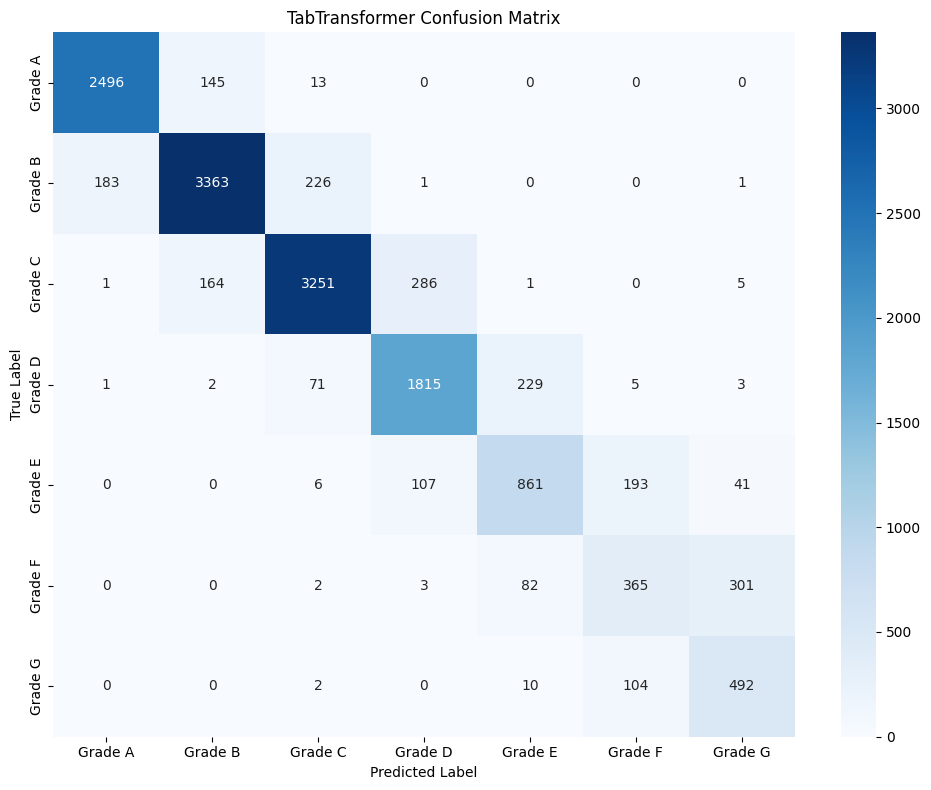

In [26]:
# Evaluate TabTransformer
tt_results = evaluate_model(
    tab_transformer, test_loader_tt, DEVICE,
    class_names=class_names, model_type="tab_transformer", set_name="TabTransformer Test"
)
plot_confusion_matrix(tt_results["y_true"], tt_results["y_pred"],
                      class_names=class_names, title="TabTransformer Confusion Matrix")

## 4. Results Comparison

In [ ]:
print(f"\n{'='*60}")
print(f"  RESULTS COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<20} {'Accuracy':>10} {'Bal Acc':>10} {'F1 macro':>10}")
print(f"{'-'*60}")

# ML models (CV results)
for name, gs in [("Random Forest", gs_rf), ("KNN", gs_knn), ("SVM", gs_svm)]:
    idx = gs.best_index_
    acc = gs.cv_results_["mean_test_accuracy"][idx]
    bal = gs.cv_results_["mean_test_balanced_accuracy"][idx]
    f1m = gs.cv_results_["mean_test_f1_macro"][idx]
    print(f"{name:<20} {acc:>10.4f} {bal:>10.4f} {f1m:>10.4f}  (CV)")

# DL models (test set)
print(f"{'FFNN':<20} {ffnn_results['accuracy']:>10.4f} {ffnn_results['balanced_accuracy']:>10.4f} {ffnn_results['f1_macro']:>10.4f}  (test)")

tabnet_acc = accuracy_score(y_test, y_pred_tabnet)
tabnet_bal = balanced_accuracy_score(y_test, y_pred_tabnet)
tabnet_f1m = f1_score(y_test, y_pred_tabnet, average="macro")
print(f"{'TabNet':<20} {tabnet_acc:>10.4f} {tabnet_bal:>10.4f} {tabnet_f1m:>10.4f}  (test)")

print(f"{'TabTransformer':<20} {tt_results['accuracy']:>10.4f} {tt_results['balanced_accuracy']:>10.4f} {tt_results['f1_macro']:>10.4f}  (test)")